In [ ]:
# ==========================================
# INSTALL REQUIRED LIBRARIES
# ==========================================
!pip install xgboost lightgbm shap lime

# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f1ed716a1d8742e52e43bd956ad9ba4010d923e8eea745dfe5521cb3dda1c9b3
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# ==========================================
# LOAD DATASET
# ==========================================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("credit_risk_dataset.csv")

# Display dataset information
print("Dataset Shape:", df.shape)
df.info()
df.describe()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv
Dataset Shape: (32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
# ==========================================
# DATA PREPROCESSING
# ==========================================

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Handle missing values (numerical columns only)
df = df.fillna(df.mean(numeric_only=True))

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Define features and target variable
X = df.drop("loan_status", axis=1)
y = df["loan_status"]


Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [ ]:
# ==========================================
# TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.085333,6322.086646,3.081605,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.011695,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
# ==========================================
# MODEL TRAINING
# ==========================================

# Train XGBoost model
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

# Train LightGBM model
model_lgb = LGBMClassifier()
model_lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 5663, number of negative: 20401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 933
[LightGBM] [Info] Number of data points in the train set: 26064, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.217273 -> initscore=-1.281630
[LightGBM] [Info] Start training from score -1.281630


LGBMClassifier()

In [ ]:
# ==========================================
# MODEL EVALUATION
# ==========================================

# Predictions
y_pred_xgb = model_xgb.predict(X_test)
y_pred_lgb = model_lgb.predict(X_test)

# XGBoost metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

# LightGBM metrics
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

# Create results table
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [accuracy, accuracy_lgb],
    "Precision": [precision, precision_lgb],
    "Recall": [recall, recall_lgb],
    "F1 Score": [f1, f1_lgb]
})

print("\nModel Performance:\n")
print(results)


Model Performance:

      Model  Accuracy  Precision    Recall  F1 Score
0   XGBoost  0.934172   0.950355  0.741869  0.833269
1  LightGBM  0.933712   0.964253  0.728028  0.829653


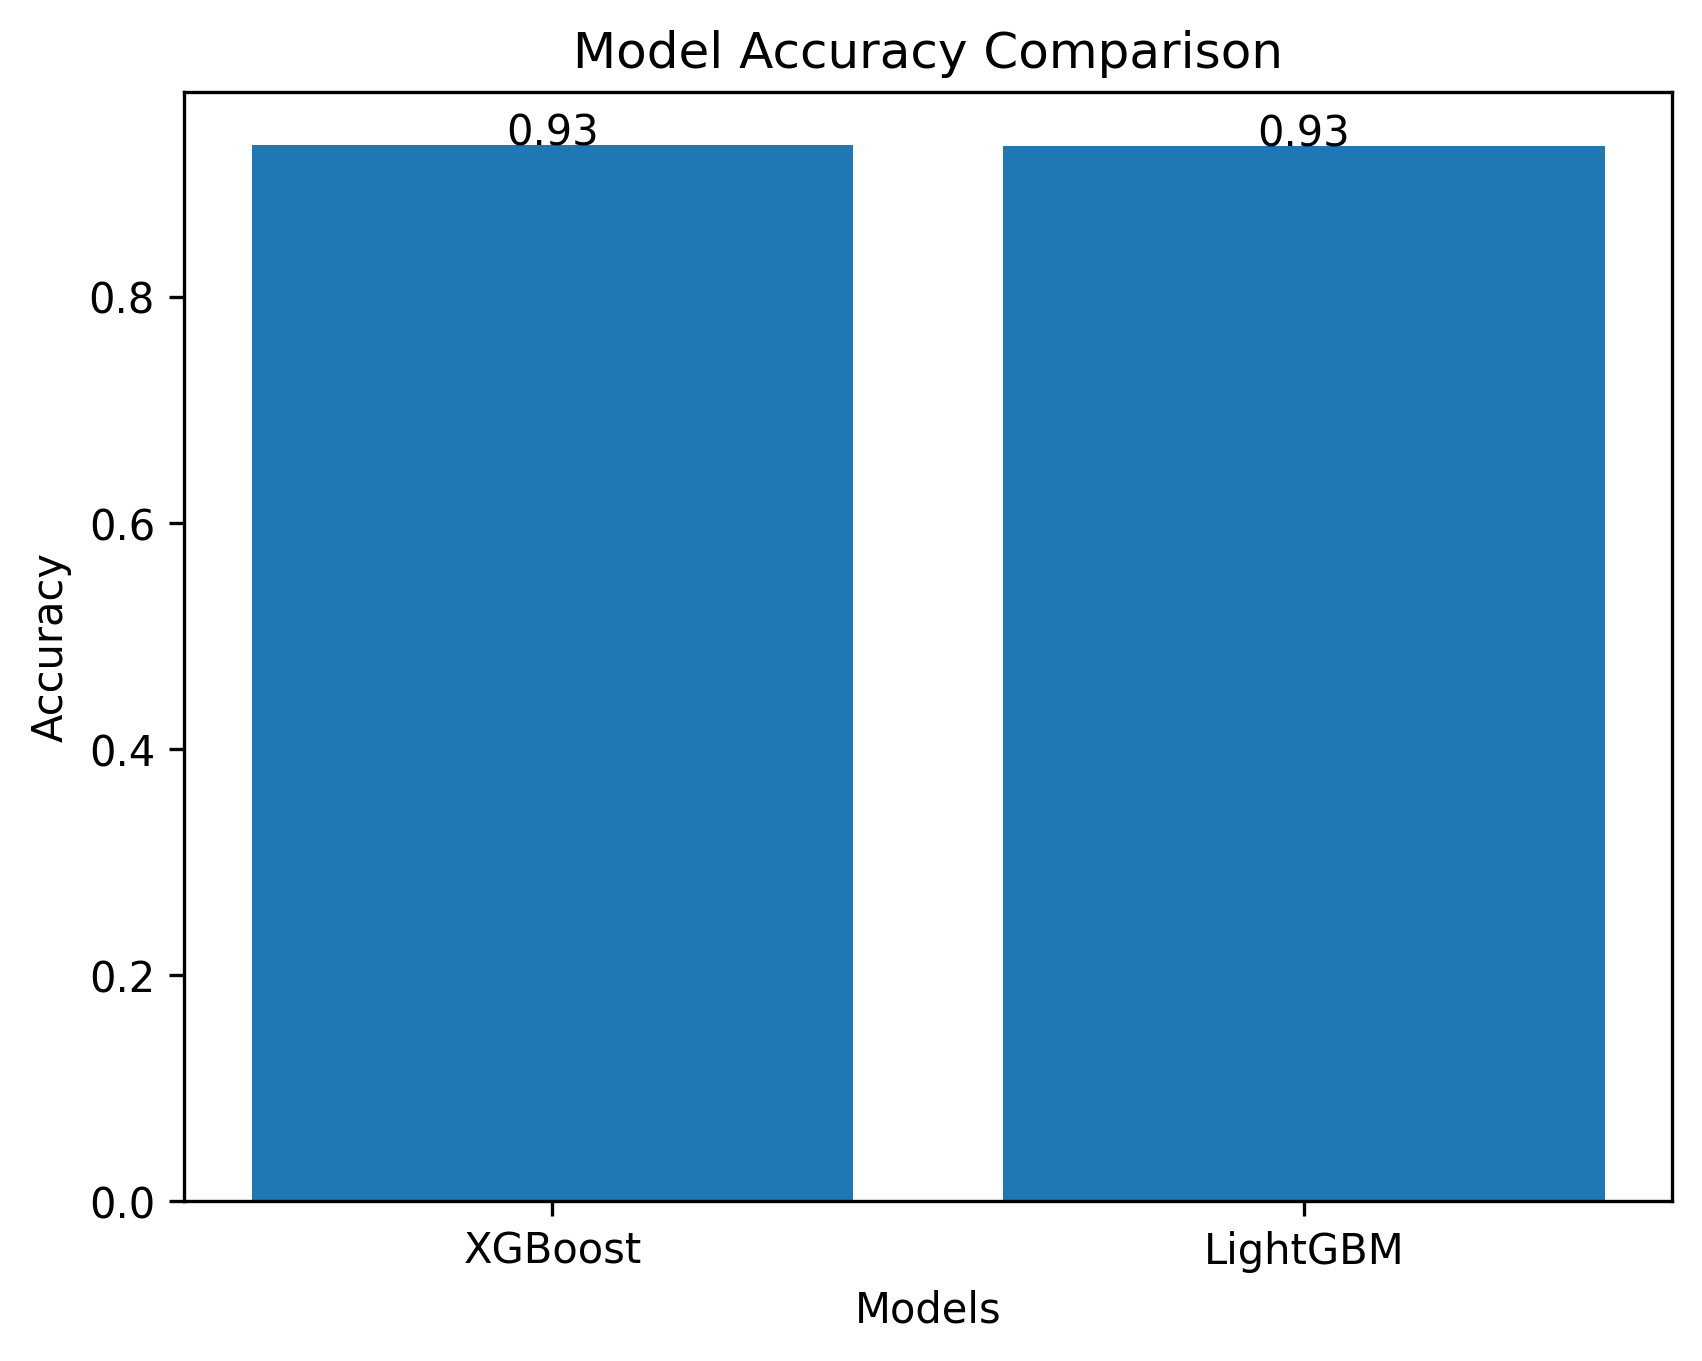

In [ ]:
# MODEL ACCURACY COMPARISON
plt.figure(dpi=300)
plt.bar(models, accuracy_scores)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy_scores):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.savefig("model_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

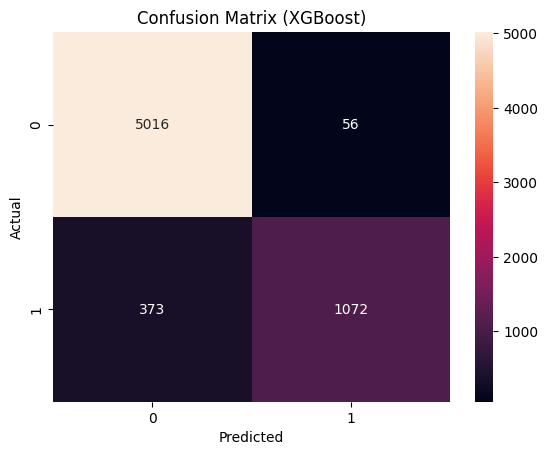

<Figure size 1920x1440 with 0 Axes>

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.figure(dpi=300)
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

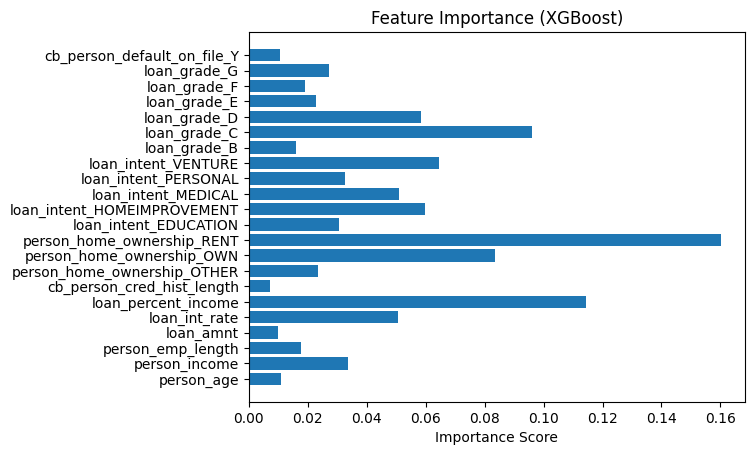

<Figure size 1920x1440 with 0 Axes>

In [ ]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = model_xgb.feature_importances_

plt.figure()
plt.barh(X.columns, importances)

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")

plt.figure(dpi=300)
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

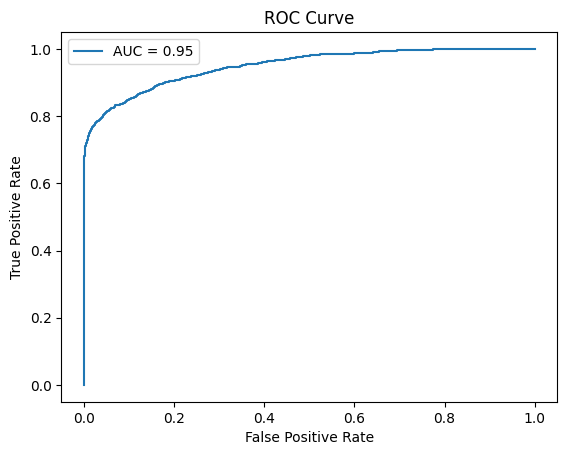

<Figure size 1920x1440 with 0 Axes>

In [ ]:
# ==========================================
# ROC CURVE
# ==========================================

y_prob = model_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.figure(dpi=300)
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ==========================================
# SHAP EXPLAINABILITY
# ==========================================

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False)

plt.savefig("shap_plot.png", dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# ==========================================
# DOWNLOAD OUTPUT FILES
# ==========================================
from google.colab import files

files.download("model_accuracy.png")
files.download("confusion_matrix.png")
files.download("feature_importance.png")
files.download("roc_curve.png")
files.download("shap_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>